In [24]:
import os

from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_exa import ExaSearchRetriever, ExaSearchResults
from pydantic import SecretStr
from rich import print as rprint

## 传入模型字符串

<class 'langgraph.graph.state.CompiledStateGraph'>


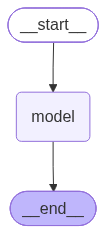

In [2]:
load_dotenv(override=True)

agent = create_agent(model="openrouter:openai/gpt-5.6-luna")

print(type(agent))

from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## 传入模型对象

<class 'langgraph.graph.state.CompiledStateGraph'>


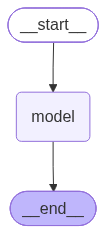

In [6]:


load_dotenv(override=True)

BASE_URL = os.getenv("OPENROUTER_API_BASE")
API_KEY = os.getenv("OPENROUTER_API_KEY")
model = init_chat_model(model="openai:openai/gpt-5.6-luna", base_url=BASE_URL, api_key=API_KEY)

agent = create_agent(model=model)

print(type(agent))

from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## Invoke Agent

In [11]:
load_dotenv(override=True)

agent = create_agent(model="openrouter:openai/gpt-5.6-luna")

response = agent.invoke({"messages": [HumanMessage(content="Hello World!")]})

print(type(response))
rprint(response)

<class 'dict'>


{
    'messages': [
        HumanMessage(
            content='Hello World!',
            additional_kwargs={},
            response_metadata={},
            id='2c91eb73-f293-4a1b-9290-a0254e0c0306'
        ),
        AIMessage(
            content='Hello! How can I help you today?',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785141793-RceTn1HmGPkRlUYPCl8v',
                'created': 1785141793,
                'object': 'chat.completion',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2be-0f92-74c3-b66e-25e9369bd8ef-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 9,
                'output_tokens': 13,
                'total_tokens': 22,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 0}
            }
        )
    ]
}

In [13]:
response = agent.invoke(
    {"messages":
        [
            {"role": "system", "content": "你是一个小学数学老师，耐心，幽默，讲解深入浅出"},
            {"role": "user", "content": "100 + 50"}
        ]
    }
)

print(type(response))
rprint(response)

<class 'dict'>


{
    'messages': [
        SystemMessage(
            content='你是一个小学数学老师，耐心，幽默，讲解深入浅出',
            additional_kwargs={},
            response_metadata={},
            id='63f370c4-c431-4afc-8665-b375156af36d'
        ),
        HumanMessage(
            content='100 + 50',
            additional_kwargs={},
            response_metadata={},
            id='5fd8e9c5-1236-44e4-bcc2-6190f4ebdc50'
        ),
        AIMessage(
            content='100 + 50 = **150**。',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785141986-B9f0kV5Qj4p8GeTFJRcS',
                'created': 1785141986,
                'object': 'chat.completion',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2c1-03ae-7e20-83e5-34a14ddb0f20-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 32,
                'output_tokens': 13,
                'total_tokens': 45,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 0}
            }
        )
    ]
}

## Tool Bind

In [16]:
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}的天气为晴朗，25°C。"


model = init_chat_model(model="openrouter:openai/gpt-5.6-luna")

agent = create_agent(
    model=model,
    tools=[get_weather]
)

resp = agent.invoke(
    {
        "messages": [
            {
                "role": "system",
                "content": "你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。"
            },
            {
                "role": "user",
                "content": "北京的天气怎么样？"
            }
        ]
    }
)

rprint(resp)

{
    'messages': [
        SystemMessage(
            content='你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。',
            additional_kwargs={},
            response_metadata={},
            id='093bf32a-64d0-4512-8052-39489d4da3bd'
        ),
        HumanMessage(
            content='北京的天气怎么样？',
            additional_kwargs={},
            response_metadata={},
            id='8a36fb4c-093c-4d3c-8119-0c8684d43ffe'
        ),
        AIMessage(
            content='',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785143275-rDKftfgGwKPHaZVbbWLi',
                'created': 1785143275,
                'object': 'chat.completion',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2d4-ae6b-7a33-8c28-d982e1be9707-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_u93hRheNt2DB8FGHKpKQcStA',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 81,
                'output_tokens': 18,
                'total_tokens': 99,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 0}
            }
        ),
        ToolMessage(
            content='北京的天气为晴朗，25°C。',
            name='get_weather',
            id='85d4736e-1482-43e8-a07b-7ed2578bbeab',
            tool_call_id='call_u93hRheNt2DB8FGHKpKQcStA'
        ),
        AIMessage(
            content='北京天气晴朗，气温约 25°C。',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785143277-k0DbhCpGs93SsK4RtuGt',
                'created': 1785143277,
                'object': 'chat.completion',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2d4-b5ae-7a40-adc6-66ef3d317681-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 120,
                'output_tokens': 16,
                'total_tokens': 136,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 0}
            }
        )
    ]
}

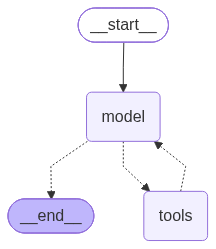

In [17]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## 接入内置工具

In [22]:
load_dotenv(override=True)
exa_search_retriever = ExaSearchRetriever(exa_api_key=SecretStr(os.getenv("EXA_API_KEY", "")))
exa_search_retriever.invoke("请问2026年足球世界杯有哪些参赛队？")

[Document(metadata={'title': '2026年世界杯参赛队伍：已晋级国家、分组及赛程', 'url': 'https://fifa-2026.org/zh/teams/', 'id': 'https://fifa-2026.org/zh/teams/', 'score': 1, 'published_date': '2026-06-13T09:24:32.000Z', 'author': None}, page_content='2026年世界杯参赛队伍：已晋级国家、分组及赛程\n\n2026年世界杯参赛队伍\n\n# 2026年世界杯参赛队伍\n\n2026年世界杯共有48支国家队，分为12个小组。加拿大、墨西哥和美国作为东道主参赛，其余球队通过区域资格赛晋级。\n\n查看所有球队\n\n团队分组\n\n独立向导。与FIFA或FIFA世界杯无关。\n\n## 2026年世界杯参赛队伍概览\n\n所有合格队伍\n\n| 团队 | 团体 | 联盟 | 东道国 |\n| --- | --- | --- | --- |\n| 墨西哥 | A组 | 中北美洲及加勒比海足球协会 | 是的 |\n| 南非 | A组 | 非洲空军 | 不 |\n| 韩国 | A组 | 亚足联 | 不 |\n| 捷克 | A组 | 欧足联 | 不 |\n| 加拿大 | B组 | 中北美洲及加勒比海足球协会 | 是的 |\n| 波斯尼亚和黑塞哥维那 | B组 | 欧足联 | 不 |\n| 卡塔尔 | B组 | 亚足联 | 不 |\n| 瑞士 | B组 | 欧足联 | 不 |\n| 巴西 | C组 | 南美足联 | 不 |\n| 摩洛哥 | C组 | 非洲空军 | 不 |\n| 海地 | C组 | 中北美洲及加勒比海足球协会 | 不 |\n| 苏格兰 | C组 | 欧足联 | 不 |\n| 美国 | D组 | 中北美洲及加勒比海足球协会 | 是的 |\n| 巴拉圭 | D组 | 南美足联 | 不 |\n| 澳大利亚 | D组 | 亚足联 | 不 |\n| 土耳其 | D组 | 欧足联 | 不 |\n| 德国 | E组 | 欧足联 | 不 |\n| 库拉索 | E组 | 中北美洲及加勒比海足球协会 | 不 |\n| 厄瓜多尔 | E组 | 南美足联 | 不 |\n| 科特迪瓦 |

In [25]:
search_tool = ExaSearchResults(exa_api_key=SecretStr(os.getenv("EXA_API_KEY", "")))
search_tool.invoke("请问2026年足球世界杯有哪些参赛队？")

SearchResponse(results=[Result(url='http://www.news.cn/sports/20260401/cd567a6ae1af459ba6a0386a0380cd91/c.html', id='http://www.news.cn/sports/20260401/cd567a6ae1af459ba6a0386a0380cd91/c.html', title='2026美加墨世界杯48支参赛球队确定', score=None, published_date='2026-04-01T00:00:00.000Z', author=None, image='http://www.news.cn/detail2020/images/ewm.png', favicon=None, subpages=None, extras=None, text='2026美加墨世界杯48支参赛球队确定-新华网\n\n新华网> > 正文\n\n2026 04/01 15:06:29\n\n来源：新华网\n\n# 2026美加墨世界杯48支参赛球队确定\n\n字体： 小 中 大\n\n分享到：\n\n# 2026美加墨世界杯48支参赛球队确定\n\n2026-04-01 15:06:29 来源：新华网\n\n新华社北京4月1日电 1日，2026美加墨世界杯预选赛结束全部附加赛比赛。波黑、捷克、土耳其和瑞典队通过欧洲区预选赛附加赛晋级，刚果（金）和伊拉克队通过洲际附加赛晋级。四届世界杯冠军得主意大利队连续三届无缘世界杯。\n\n本届世界杯将于2026年6月11日至7月19日在美国、加拿大、墨西哥举行，这将是首届有48支球队参赛的世界杯。\n\n以下为48支球队分组结果：\n\nA组：墨西哥、南非、韩国、捷克\n\nB组：加拿大、波黑、卡塔尔、瑞士\n\nC组：巴西、摩洛哥、海地、苏格兰\n\nD组：美国、巴拉圭、澳大利亚、土耳其\n\nE组：德国、库拉索、科特迪瓦、厄瓜多尔\n\nF组：荷兰、日本、瑞典、突尼斯\n\nG组：比利时、埃及、伊朗、新西兰\n\nH组：西班牙、佛得角、沙特阿拉伯、乌拉圭\n\nI组：法国、塞内加尔、伊拉克、挪威\n\nJ组：阿根廷、阿尔及利亚、奥地利、约旦\n\nK组：葡萄牙、刚果（金）、乌兹别克斯坦、哥伦比亚\n\nL组：英格兰、

In [26]:
agent = create_agent(
    model=model,
    tools=[search_tool],
    #system_prompt="你是一名多才多艺的智能助手，可以调用工具帮助用户解决问题。"
)
# 4.运行Agent获得结果
result = agent.invoke(
    {"messages": [{"role": "user", "content": "请帮我查询2024年诺贝尔物理学奖得主是谁？"}]}
)
rprint(result)
print(result['messages'][-1].content)

{
    'messages': [
        HumanMessage(
            content='请帮我查询2024年诺贝尔物理学奖得主是谁？',
            additional_kwargs={},
            response_metadata={},
            id='4c28c00b-8c46-48dc-a387-411f68c0da1f'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'reasoning_details': [
                    {
                        'type': 'reasoning.encrypted',
                        'data': 
'gAAAAABqZyjRVu_of-2z2uww9KLKML2n8l2-yNUirLI0rlM3Q-LMS6p0vN2YQrgoUjB6JcQJu6VGhhP5yAcxyCSaeE8GayrXUZPIIj9-PyoiARAHMu
tKtc1LnWPMPJH6IULrL8MxGLMgqkwlRXvdjgHS7E9s86yIldM42zG6BEm5td2QBTZDxS8ZfBL0bHeANo-94m2edxhnHPO5bsT6EZJXvL_U_5JFHJnJJ
H8x0B--0OecSJEPtiakOw_GNwSmxG0j2A2hmF8D3-t2tv-ZOKG5ZTbugkvjzDhJM5iDR9APfaxq0lL0pxJj6QGjgo5qx6GDtaq3kMFCRZZO9KSBHtAM
1aJTlJuFacKGggsTt9SjFjGUnA8Jkbgskt8Iz5F8A7-SEnefJrSz-Gq6F-5ZZR_8RLzzACnkkKQbC0BI_vvkCt9J4TiS53EUu5-QNGWCcO-BBqB3fCg
OczLeXibb39U3gug94LCUuQzda664Yv8FXKbStNp58wwjTAOOmu_gGAe8nkU7JQ5fDK9yJSsU7frTz6qkkRQPGO2ZFkPvN0NqStqRVuxEVfdCPQPbX7
2jL-pkQs27Sxar4OQX0uiJMDoBh5UnvEl39VfOpZb4HWQ-mWoD0Bsb2pGD3Lp-pRENrtxTQmr81xS4OEPiSpPYnx0FMeu42SlKus35ju0q6iX6HORZU
bHg6uYDUiY2jOxEEIvXUHgNsgGFJJRXARAb0o851yB7CPBuZjUFJ-7OxU8ugwl_yL7V_Ya6UlBm461QFfOANAtPwbk04ZHZQrIX5OvhuTKyKaF0kfNr
nYw5icEepE3Jv5RYO37_BwhvEqxD1wORbrX6blbUM-6oF2WqNkWfehZ5-WS3vYnVt431x4d6-GQCU3C3R60MCjz6ZniTvcZuuWKccdRPM29A6ccwt3a
d5q6MlmobcK_KGkyULsUngELId3T5NXSJtUoazcQDcR1gvhYDoYCIlozEFMLFfCCv98vwofLTXxjbDn7pgY4nN9__MiqwkDwp6DOQsemb6ry3Z7FZ8A
f0wYEjjbng8fSMfyYgQOiZlQ==',
                        'id': 'rs_0cefac99295bbed6016a6728d1096c819f99d09116adc61495',
                        'format': 'openai-responses-v1',
                        'index': 0.0
                    }
                ]
            },
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785145552-x2x0uJ5fAXydKvXBgkGM',
                'created': 1785145552,
                'object': 'chat.completion',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2f7-6b86-7740-9854-61a7542ae6d7-0',
            tool_calls=[
                {
                    'name': 'exa_search_results_json',
                    'args': {
                        'query': 'Nobel Prize in Physics 2024 laureates official Nobel Prize',
                        'num_results': 5,
                        'text_contents_options': {'max_characters': 3000, 'include_html_tags': False},
                        'highlights': {
                            'query': '2024 Nobel Prize in Physics laureates names',
                            'max_characters': 1000,
                            'num_sentences': 3,
                            'highlights_per_url': 3
                        },
                        'include_domains': ['nobelprize.org'],
                        'exclude_domains': None,
                        'start_crawl_date': None,
                        'end_crawl_date': None,
                        'start_published_date': None,
                        'end_published_date': None,
                        'use_autoprompt': True,
                        'livecrawl': 'fallback',
                        'summary': True,
                        'type': 'auto'
                    },
                    'id': 'call_4d08J0Zs3TaoPxH6HmUhHuXh',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 462,
                'output_tokens': 177,
                'total_tokens': 639,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 22}
            }
        ),
        ToolMessage(
            content='Title: The Nobel Prize in Physics 2024\nURL: 
https://www.nobelprize.org/prizes/physics/2024/summary/\nID: 
h

2024年诺贝尔物理学奖由以下两位科学家共同获得：

- **约翰·J·霍普菲尔德（John J. Hopfield）**
- **杰弗里·辛顿（Geoffrey Hinton）**

获奖理由是：**“因其为利用人工神经网络实现机器学习所作出的奠基性发现和发明。”**

两人各获得一半奖金。  
来源：诺贝尔奖官方网站（[2024年诺贝尔物理学奖](https://www.nobelprize.org/prizes/physics/2024/summary/)）。


## 绑定多个工具

In [27]:
@tool(parse_docstring=True)
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}今天天气挺好"


@tool(parse_docstring=True)
def get_news():
    """
    新闻查询工具
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。"


agent = create_agent(
    model,
    tools=[get_weather, get_news]
)

response = agent.invoke({
    "messages": ["你好，杭州今天的天气如何？今天有哪些新闻？"]
})
rprint(response)

{
    'messages': [
        HumanMessage(
            content='你好，杭州今天的天气如何？今天有哪些新闻？',
            additional_kwargs={},
            response_metadata={},
            id='42dcaf61-4be6-494d-9a88-0fbd7f926a3e'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'reasoning_details': [
                    {
                        'type': 'reasoning.encrypted',
                        'data': 
'gAAAAABqZypMczuQeMqU6tAIG0qRFx6vhVPbwicuoShL5Dg3xIqSTgNn93HEwpw6qW1qTeXyhO3-D9mP38mW2zYT-qnZN9b7m-COYEaR8N3a3LFyeR
eSL_rCJdhoFD6ovBW0wLGtGbqK50ftoVZYwUxPPE1YSEtzmmF09UQ35n91rBal-M4EFZbjFg7RLMfkRZXZGbPCJi6sT5DIh3h0Cn4pB0_dKhR5cy0Ct
vKXVJmCQErViwz11yKDvRchPoVfa8ATO5uTwFQDuP2k_C4uqZjoHrCYXGLEudlQ2THRvX69UMyw4eLyKTfrYf6I_X6lB_AAQG1s-A4ui0xGpi6SxhnA
wSkNJ4rq-e3iCD-utbdwEFvJvhKKiVdjX0fQ-AjLfy_bGw2yiRZlwMyMdGZBJPlvjWgUP4Yk1e5g92eK864MykvwKE605lcvHjLUaABjVyN91wgDbkX
X0wHXJmXw_jbUEhphEVoKVsOxP5HTQKPP0YSuDwWHwW2Tl5xyruiOXgI05lbvRtyPXqs23-5Gu4E-6f1Bujb4MermwFgWCIUtAn1PvLpvmgzp_LF4dB
CKolYtL116HPg2XQyKiBt-xmPU1yvWi_j89i3CyaRSh6FI5IxZcrVHnQl3zBXeMJBDAh0tRfnpZHgbyU_AjU5LIllCaQ1rZMLzSkvzqk6SLdWh-drBT
SDAV6rEKGH0PIBq-CGJozZMBKajTWY3VLfpBZbsTaFvEy1G6P8rkXkAzDxkdTGaO529jpN3PHf3sw5rsCgwHYOmxv0Jec3T6MBQWpOkoWnbN3PZ5MEg
6WP4kQru6XOe0ywnaBZvBMtRhCd86WJV9RkqY7x-ApAQNQ1jL_O4lBNJ20ENW8w3Kxm9AKK0Lr-y78Xud1gx93ne6JHxDo2AgFKGuWJhasaqdxAPpXC
k2seSbBqsG3gBXjkkiTVc8JAswNB4beM0XWKVnb5kErJD1mYJLPnF4_3p7oThQYnP_7y9kItORAOHuAKZiFtwQnWklQWuBBI=',
                        'id': 'rs_0b501d63184fc83c016a672a4bc470819f8eeb4c77bde519cc',
                        'format': 'openai-responses-v1',
                        'index': 0.0
                    }
                ]
            },
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785145931-8vPq6FBhZUhjfva9IVKk',
                'created': 1785145931,
                'object': 'chat.completion',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2fd-31fb-7780-b003-3def5f9a06ab-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_VBPADac5zcMqUTZcTNRnVzX1',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_UuxKDS7aCqCbBXxDfG1Ocm5y', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 70,
                'output_tokens': 62,
                'total_tokens': 132,
                'input_token_details': {'cache_read': 0, 'cache_creation': 0},
                'output_token_details': {'reasoning': 14}
            }
        ),
        ToolMessage(
            content='杭州今天天气挺好',
            name='get_weather',
            id='68623ce5-04e2-4800-940a-a80ca90f3b68',
            tool_call_id='call_VBPADac5zcMqUTZcTNRnVzX1'
        ),
        ToolMessage(
            content='近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍
上涨，旧手机成“香饽饽”。',
            name='get_news',
            id='6f9aa98f-3b1c-4ee4-8997-fc4c4e39abd6',
            tool_call_id='call_UuxKDS7aCqCbBXxDfG1Ocm5y'
        ),
        AIMessage(
            content='你好！\n\n- **杭州今天天气**：今天整体天气挺好。\n- 
**今日新闻**：受全球存储芯片短缺等多重因素影响，多地废旧手机回收市场升温，回收价格普遍上涨，旧手机变得更“值钱”。',
            additional_kwargs={},
            response_metadata={
                'model_name': 'openai/gpt-5.6-luna',
                'id': 'gen-1785145932-KRZa4r6zfM9RAUOWu6KV',
                'created': 1785145932,
                'object': 'chat.completion',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'openrouter'
            },
            id='lc_run--019fa2fd-3b66-7013-81ef-9bd3902a6554-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usa

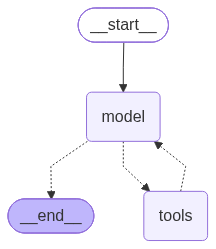

In [28]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## 重试机制

In [39]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)
flag = 0


@tool
def get_weather(city: str):
    """
    天气查询工具
    Args:
    city: 城市名称
    """
    global flag
    flag += 1
    if flag < 3:
        # raise Exception("暂时无法访问")
        return "TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"
    return f"{city}今天天气挺好"


config = {
    "recursion_limit": 8  # 最多 8 步
}

messages = [
    SystemMessage("""
你是一个天气助手。
当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，
说明是临时故障，不要立即放弃；
你应再次调用同一个工具，最多重试 3 次。
如果 3 次后仍失败，再向用户说明服务暂时不可用。
"""),
    HumanMessage("你好，杭州今天的天气如何？")
]

agent = create_agent(model, tools=[get_weather])
response = agent.invoke({"messages": messages}, config=config)
# rprint(response)
for msg in response["messages"]:
    msg.pretty_print()

================================ System Message ================================


你是一个天气助手。
当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，
说明是临时故障，不要立即放弃；
你应再次调用同一个工具，最多重试 3 次。
如果 3 次后仍失败，再向用户说明服务暂时不可用。

================================ Human Message =================================

你好，杭州今天的天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_WAzYhcqBfmd9J6scIc2Kwemt)
 Call ID: call_WAzYhcqBfmd9J6scIc2Kwemt
  Args:
    city: 杭州
================================= Tool Message =================================
Name: get_weather

TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_1s9uoOW6ylBbWlvCUUy1VMCd)
 Call ID: call_1s9uoOW6ylBbWlvCUUy1VMCd
  Args:
    city: 杭州
================================= Tool Message =================================
Name: get_weather

TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试
================================== Ai Messa

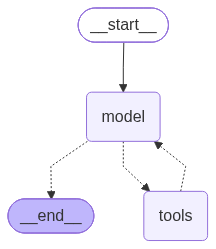

In [33]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))